# Read the .pts file

In [63]:
from pathlib import Path
import pandas as pd
import numpy as np


scans_dir = Path("/home/fzhcis/mylab/data/inlut3d/setup_2")
scan_path = scans_dir / "setup_2.pts"
scan_path.exists()

from tools.preprocess_point_cloud import read_and_clean_pcd

df = read_and_clean_pcd(scan_path)

Reading a .pts file, for In_LUT3D data.
Read 11630820 points from /home/fzhcis/mylab/data/inlut3d/setup_2/setup_2.pts
---------Before preprocessing:----------
Range of X: -7.363 to 2.038
Range of Y: -2.905 to 19.281
Range of Z: -1.104 to 4.340
Range of r: 0.000 to 255.000
Range of g: 0.000 to 255.000
Range of b: 0.000 to 255.000
Range of class_id: -1.000 to 17.000
Range of instance_id: -1.000 to 18.000
Range of Intensity: 0.001 to 1.000
Range of Return Number: 1.000 to 1.000
Range of azimuth: 0.045 to 359.955
Range of elevation: -60.742 to 89.954
Range of zenith: 0.046 to 150.742
Range of rangemeter: 0.782 to 20.577
!!Intensity normalized to range: 0.0 to 1.0!!
---------After preprocessing:----------
Range of X: -7.363 to 2.038
Range of Y: -2.905 to 19.281
Range of Z: -1.104 to 4.34
Range of r: 0 to 255
Range of g: 0 to 255
Range of b: 0 to 255
Range of class_id: -1 to 17
Range of instance_id: -1 to 18
Range of Intensity: 0.0 to 1.0
Range of Return Number: 1 to 1
Range of azimuth: 0.04

In [64]:
def read_pts_file(file_path):
    # Read the file
    with open(file_path, 'r') as f:
        lines = f.readlines()

    # First line is the number of points, skip it
    data_lines = lines[1:]

    # Convert to DataFrame
    from io import StringIO
    data_str = ''.join(data_lines)
    df = pd.read_csv(StringIO(data_str), sep='\s+', header=None)
    df.columns = ["X", "Y", "Z", "r", "g", "b", "class_id", "instance_id"]

    return df


In [65]:
df.head()

,X,Y,Z,r,g,b,class_id,instance_id,Intensity,Return Number,azimuth,elevation,zenith,rangemeter
0,0.02,-0.026,1.749,199,199,199,0,0,0.780105,1,307.568592,88.925545,1.074455,1.749308
1,0.02,-0.026,1.748,199,199,199,0,0,0.780105,1,307.568592,88.924931,1.075069,1.748308
2,0.02,-0.026,1.749,199,199,199,0,0,0.780105,1,307.568592,88.925545,1.074455,1.749308
3,0.02,-0.026,1.751,201,201,201,0,0,0.787958,1,307.568592,88.926772,1.073228,1.751307
4,0.02,-0.026,1.752,197,197,197,0,0,0.772251,1,307.568592,88.927385,1.072615,1.752307


/tmp/ipykernel_255545/57919809.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap("viridis", len(unique_values))


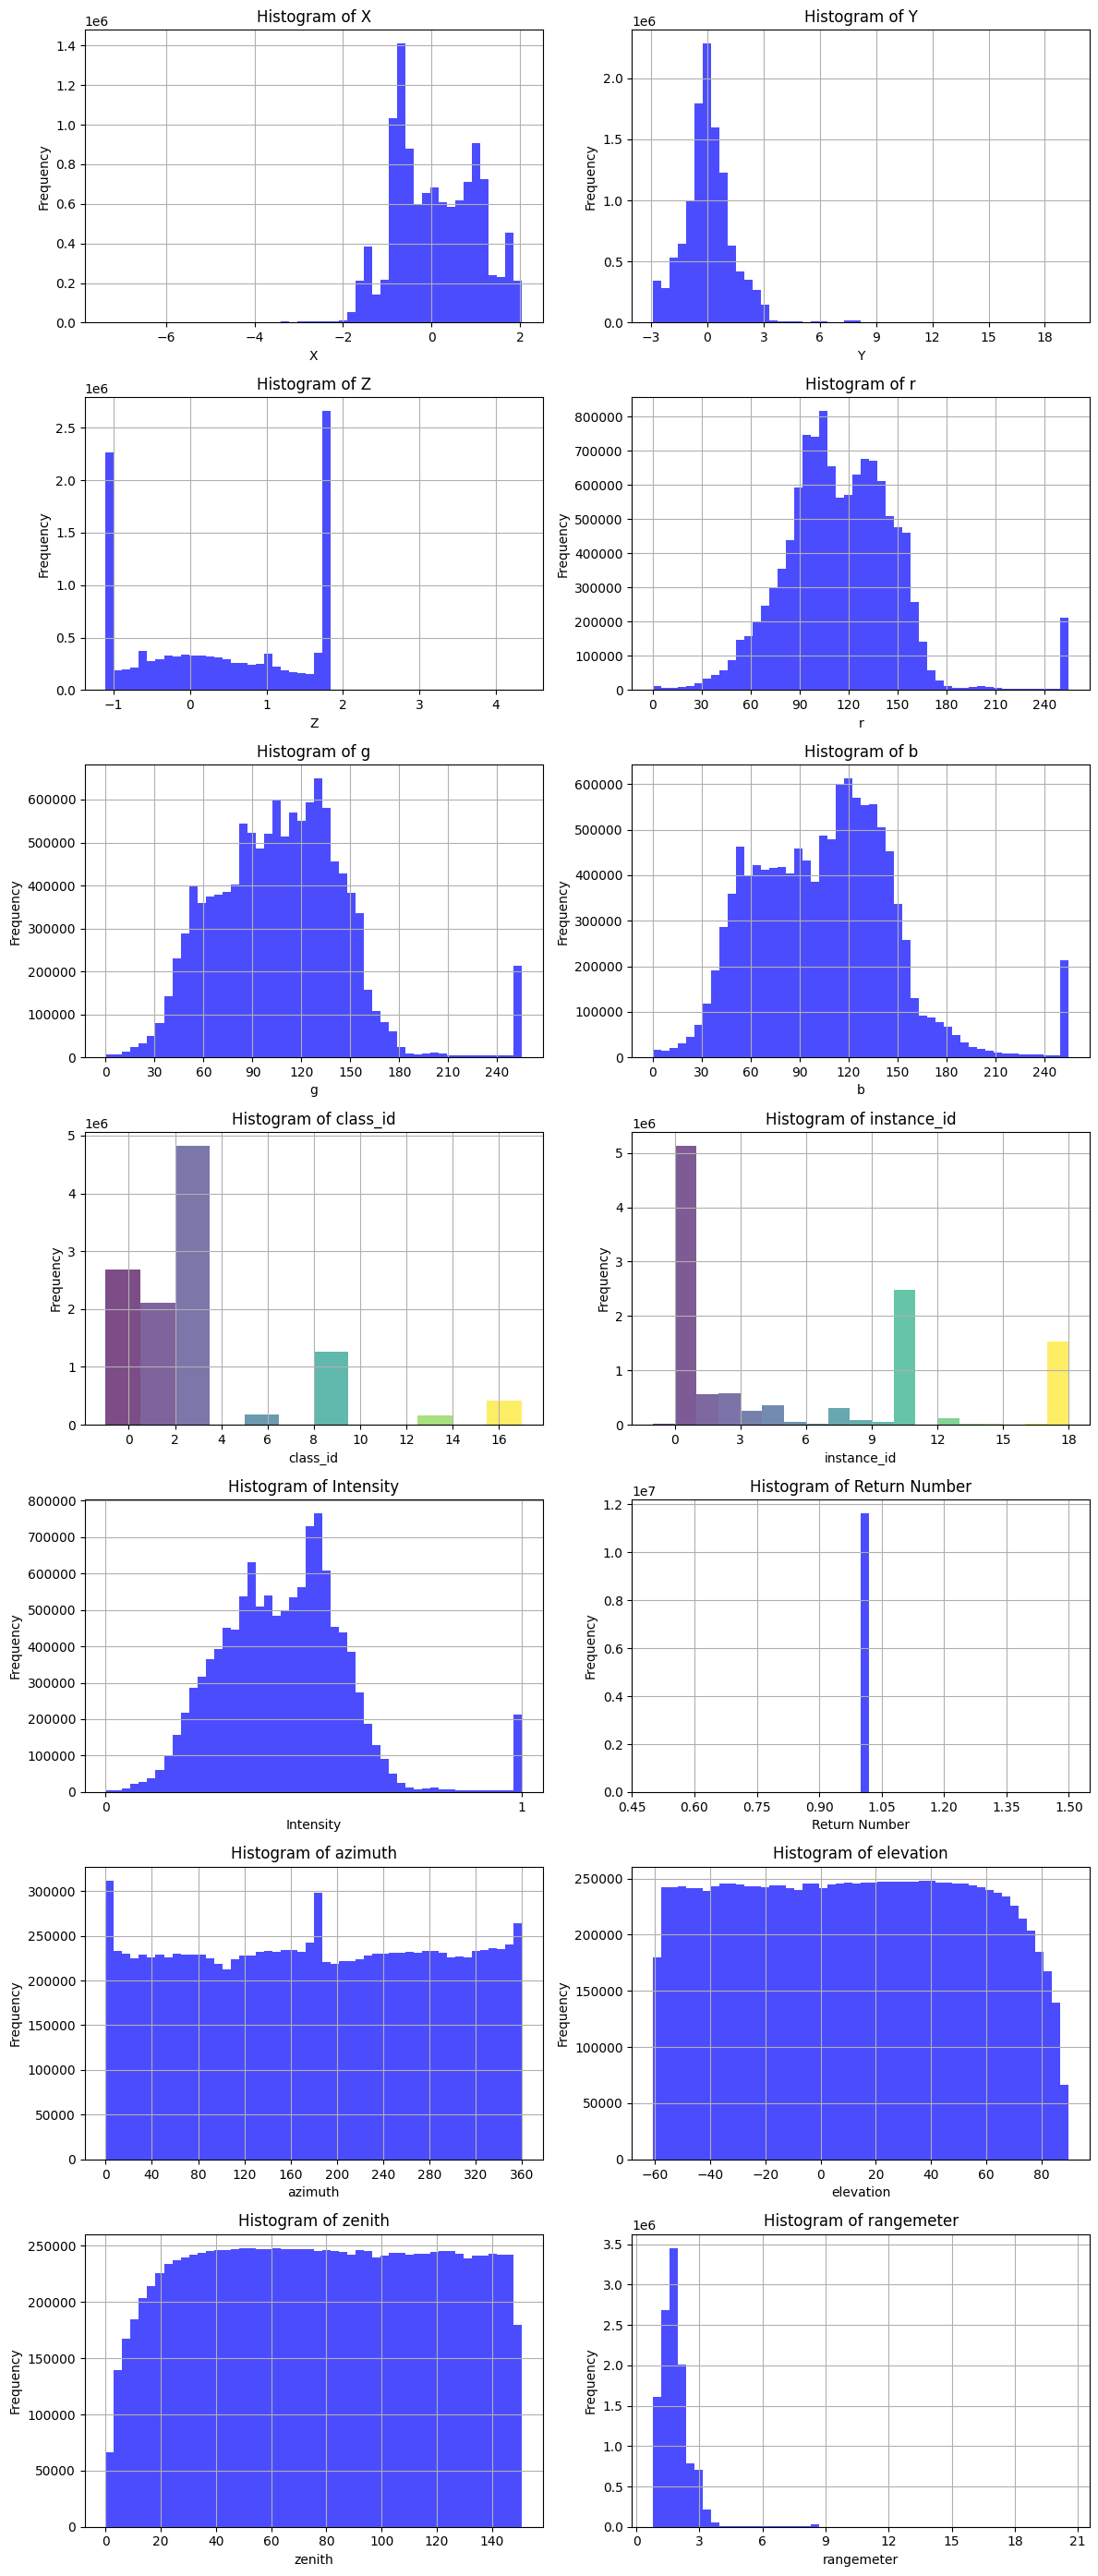

In [66]:
# Plot histograms of each column of the DataFrame, stack them in a [n_columns x 1] grid

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib.colors as mcolors



def plot_histograms(df):
    columns = df.columns
    n_columns = len(columns)

    n_rows = (n_columns + 1) // 2  # Two columns per row
    fig = plt.figure(figsize=(12, 4 * n_rows))
    gs = gridspec.GridSpec(n_rows, 2, figure=fig)
    for i, column in enumerate(columns):
        ax = fig.add_subplot(gs[i // 2, i % 2])
        if column == "class_id" or column == "instance_id":
            # Use a color map for categorical data
            unique_values = df[column].unique()
            cmap = cm.get_cmap("viridis", len(unique_values))
            norm = mcolors.BoundaryNorm(boundaries=np.arange(len(unique_values) + 1), ncolors=len(unique_values))
            colors = [cmap(norm(i)) for i in range(len(unique_values))]
            hist, bins = np.histogram(df[column], bins=len(unique_values))
            ax.bar(bins[:-1], hist, width=np.diff(bins), align='edge', color=colors, alpha=0.7)
        else:
            ax.hist(df[column], bins=50, alpha=0.7, color='blue')


        ax.set_title(f"Histogram of {column}")
        ax.set_xlabel(column)
        ax.set_ylabel("Frequency")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.grid(True)
    plt.tight_layout()
    plt.show()


plot_histograms(df)

In [79]:
360/2048

0.17578125